## 1. Introduction and objectives

The previous notebook built and evaluated four models under an honest, patient-grouped, resample-in-fold protocol, and established the trustworthy target band: neural networks 0.58-0.61 AUROC, gradient boosting 0.63-0.70, LACE 0.56. The untuned test results are carried forward from `artifacts/results_phase3.json`.

This notebook applies a disciplined, comparable hyperparameter search to Model A and Model B. The aim is not to chase a large improvement - the dataset's ceiling is genuine and low - but to search properly and report the outcome either way. "Tuning did not help" is a legitimate result here.

### 1.1 Hyperparameter search is a zero-order (direct) search

Direct search treats the objective - here, validation AUROC - as a black box and samples it, rather than differentiating it. Two variants: grid search (even sampling on a lattice) and random search (random sampling, which often finds a better optimum for the same budget).

Tuning is this kind of search for a structural reason: the validation objective is not differentiable with respect to a hyperparameter like the number of hidden units or the optimiser choice - those change which function gradient descent optimises, not a point on a differentiable surface. That is why parameter learning (the four-stage `fit()` loop) and hyperparameter selection are two different procedures. The known weakness of direct search is that a large space against a finite trial budget threatens both time and accuracy; Section 5 sizes our space against exactly that, and Section 7 reports wall-clock and trials-to-best for each strategy.

### 1.2 Model parameters vs. hyperparameters

| | Model parameters | Hyperparameters |
|---|---|---|
| Examples | Layer weights `W` and biases `b` | Learning rate, batch size, units per layer, dropout, optimiser, filters/kernel size |
| Set by | Learned by gradient descent inside `model.fit()` | Chosen by a direct search around that loop |
| Differentiable objective? | Yes | No |

## 2. Setup, configuration, seeds, GPU check, load artifacts

**Import required libraries**

In [1]:
# Core stack, following the same import idiom as, plus Keras Tuner (self-learning for the Hyperband component -
import json
import random
import time
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, Conv1D, MaxPooling1D, SpatialDropout1D, Flatten
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

import keras_tuner as kt

from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    f1_score, precision_score, recall_score, accuracy_score,
)

warnings.filterwarnings("ignore")

I0000 00:00:1784871274.831555  610611 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1784871276.812294  610611 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


**Configuration - the compute budget in one place**

`SMOKE_TEST = True` forces a tiny budget so the whole notebook can be proven to run end-to-end in a few minutes before the full run; setting it to `False` restores the full budget and is the only line that needs changing. Anchor epoch times from the previous notebook (same GPU, `batch_size=256`): Model A ~2.4 s/epoch, Model B ~4.0 s/epoch. `batch_size` is itself searched below, so per-trial times vary.

In [2]:
# ============================================================================ CONFIGURATION - change the search
SMOKE_TEST = False  # <-- set to True to re-run the end-to-end smoke test

if SMOKE_TEST:
    MAX_TRIALS = 2  # trials per strategy, per model (RandomSearch/Bayesian)
    MAX_EPOCHS = 2  # max epochs per trial (also Hyperband's max_epochs)
    RETRAIN_MAX_EPOCHS = 2  # epoch cap for the final retrain
else:
    MAX_TRIALS = 30
    MAX_EPOCHS = 30
    RETRAIN_MAX_EPOCHS = 100  # the own default, now bounded
                              # by EarlyStopping + ReduceLROnPlateau instead of
                              # running unconditionally

EARLY_STOPPING_PATIENCE = 5
HYPERBAND_FACTOR = 3
RANDOM_STATE = 42

print(f"SMOKE_TEST = {SMOKE_TEST}")
print(f"MAX_TRIALS = {MAX_TRIALS}, MAX_EPOCHS = {MAX_EPOCHS}, "
      f"RETRAIN_MAX_EPOCHS = {RETRAIN_MAX_EPOCHS}")

SMOKE_TEST = False
MAX_TRIALS = 30, MAX_EPOCHS = 30, RETRAIN_MAX_EPOCHS = 100


**Seed everything**

In [3]:
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Same cwd-robust preamble as Notebooks 1 and 2 - do NOT hardcode Path("artifacts").
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
TUNING_DIR = ARTIFACTS_DIR / "tuning"
RESULTS_PHASE4_PATH = ARTIFACTS_DIR / "results_phase4.json"

pd.set_option("display.max_columns", None)

def now() -> str:
    """Timestamp helper for progress prints."""
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")

print(f"[{now()}] PROJECT_ROOT = {PROJECT_ROOT}")
print(f"[{now()}] Global RANDOM_STATE = {RANDOM_STATE}")

[2026-07-24 13:34:38] PROJECT_ROOT = .
[2026-07-24 13:34:38] Global RANDOM_STATE = 42


**GPU check**

TensorFlow is checked for GPU visibility. This run is left unbound (no memory cap), since the machine is dedicated to it; a `set_memory_growth` call is a one-line change if it needs to be shared.

In [4]:
gpu_devices = tf.config.list_physical_devices("GPU")
print(f"TensorFlow {tf.__version__}, Keras Tuner {kt.__version__}")
print(f"GPUs visible: {gpu_devices if gpu_devices else 'NONE - running on CPU'}")

TensorFlow 2.21.0, Keras Tuner 1.4.8
GPUs visible: NONE - running on CPU


E0000 00:00:1784871278.275244  610611 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_UNKNOWN: unknown error


**Load the Notebook 1/2 artifacts**

In [5]:
x_train_dense = np.load(ARTIFACTS_DIR / "x_train_dense.npy")
x_val_dense = np.load(ARTIFACTS_DIR / "x_val_dense.npy")
x_test_dense = np.load(ARTIFACTS_DIR / "x_test_dense.npy")

y_train = np.load(ARTIFACTS_DIR / "y_train.npy")
y_val = np.load(ARTIFACTS_DIR / "y_val.npy")
y_test = np.load(ARTIFACTS_DIR / "y_test.npy")

with open(ARTIFACTS_DIR / "results_phase3.json") as f:
    results_phase3 = json.load(f)

n_features = x_train_dense.shape[1]

# The (n, k, 1) reshape that makes the tabular dense matrix Conv1D-able
# .
x_train_cnn = x_train_dense.reshape(-1, n_features, 1)
x_val_cnn = x_val_dense.reshape(-1, n_features, 1)
x_test_cnn = x_test_dense.reshape(-1, n_features, 1)

print(f"Dense path -> train {x_train_dense.shape}, val {x_val_dense.shape}, test {x_test_dense.shape}")
print(f"CNN path   -> train {x_train_cnn.shape}, val {x_val_cnn.shape}, test {x_test_cnn.shape}")
print(f"Positive rate -> train {y_train.mean()*100:.2f}%, val {y_val.mean()*100:.2f}%, test {y_test.mean()*100:.2f}%")
print(f"n_features = {n_features}")

Dense path -> train (59605, 89), val (19868, 89), test (19867, 89)
CNN path   -> train (59605, 89, 1), val (19868, 89, 1), test (19867, 89, 1)
Positive rate -> train 11.39%, val 11.39%, test 11.39%
n_features = 89


**Shared evaluation helpers**

Redefined here rather than imported, so the notebook runs independently. The definitions match the previous notebook exactly, so the tuned-vs-untuned comparison in Section 10 is like-for-like.

In [6]:
def compute_extended_metrics(y_true: np.ndarray, y_proba: np.ndarray, threshold: float = 0.5) -> dict:
    """Compute the metrics the does not teach, at a given threshold."""
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
        "minority_f1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "minority_precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "minority_recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
        "threshold": threshold,
    }

def select_threshold_max_f1(y_true_val: np.ndarray, y_proba_val: np.ndarray) -> float:
    """Select the probability threshold that maximises F1 on the validation PR curve."""
    precision, recall, thresholds = precision_recall_curve(y_true_val, y_proba_val)
    f1_scores = 2 * precision * recall / (precision + recall + 1e-12)
    best_idx = np.argmax(f1_scores[:-1])
    return float(thresholds[best_idx])

def plot_learning_curves(history, model_name: str) -> None:
    """Plot loss and AUC learning curves, train vs validation."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(history.history["loss"])
    axes[0].plot(history.history["val_loss"])
    axes[0].set_title(f"{model_name} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend(["Train", "Validation"], loc="upper right")

    axes[1].plot(history.history["auc"])
    axes[1].plot(history.history["val_auc"])
    axes[1].set_title(f"{model_name} - AUC")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("AUC")
    axes[1].legend(["Train", "Validation"], loc="lower right")
    plt.tight_layout()
    plt.show()

def plot_roc_pr_curves(y_true: np.ndarray, y_proba: np.ndarray, model_name: str) -> None:
    """Plot ROC and Precision-Recall curves side by side (Notebook 2 idiom, verbatim)."""
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    roc_auc = roc_auc_score(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    axes[0].plot(fpr, tpr, label=f"AUROC = {roc_auc:.3f}", color="steelblue")
    axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title(f"{model_name} - ROC curve")
    axes[0].legend(loc="lower right")

    axes[1].plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}", color="darkorange")
    axes[1].axhline(y_true.mean(), linestyle="--", color="gray", label=f"Baseline = {y_true.mean():.3f}")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title(f"{model_name} - Precision-Recall curve")
    axes[1].legend(loc="upper right")
    plt.tight_layout()
    plt.show()

def _json_default(obj):
    """Fallback encoder for numpy scalar/array types json.dump cannot serialise directly."""
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return str(obj)

print("Evaluation helpers defined: compute_extended_metrics, select_threshold_max_f1, "
      "plot_learning_curves, plot_roc_pr_curves")

Evaluation helpers defined: compute_extended_metrics, select_threshold_max_f1, plot_learning_curves, plot_roc_pr_curves


## 3. Hyperparameters - list and explain

Everything in this table is chosen rather than learned. The search implements it directly.

| Hyperparameter | What it controls | Search range | Note |
|---|---|---|---|
| Learning rate | Step size of each gradient-descent update | `[0.001, 0.003, 0.01, 0.03, 0.1, 0.3]` | A standard half-decade grid; Section 8's range test cross-checks the chosen value |
| Batch size | Samples per gradient estimate | `[64, 128, 256, 512]` | At ~59,600 rows the usual 16/32 give 1,863-3,725 steps/epoch; larger batches suit this scale |
| Epochs | Passes over the training data | not searched; capped at 30, `EarlyStopping(patience=5)` per trial | Lets early stopping pick the stop point per configuration |
| Hidden units (Model A) | Layer width / capacity | HL1 `hp.Int(32, 256, step=32)`, HL2 `hp.Int(16, 128, step=16)` | Depth fixed at 2 layers; width searched |
| Activation | Hidden-layer non-linearity | `['relu', 'tanh']` | Tests whether the default is actually best here |
| Dropout | Fraction of units zeroed per step | `hp.Float(0.1, 0.5, step=0.1)` per layer | Searched per layer |
| Optimiser | The update rule | `['sgd', 'adam', 'rmsprop']` | The three in common use |
| Filters (Model B) | Feature detectors per `Conv1D` | `hp.Int(16, 128, step=16)` per layer | Coarse steps keep cardinality sane |
| Kernel size (Model B) | Convolution receptive field | `[2, 3]` per layer | Tests a slightly wider window |
| Pool size | Downsampling after each convolution | fixed at 2 | Larger, tunable pooling over two blocks risks a negative output length on some sampled combinations |

## 4. Search space definitions

Both hypermodels subclass `kt.HyperModel` rather than using a bare `build_model(hp)` function, which is what lets `batch_size` be tuned: overriding `HyperModel.fit()` registers any `hp.*` call made inside `fit()` into the same trial, so `best_hp.values["batch_size"]` is available after the search like every other hyperparameter.

In [7]:
# Learning-rate search grid.
LR_GRID = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3]
BATCH_SIZE_CHOICES = [64, 128, 256, 512]
OPTIMIZER_CHOICES = ["sgd", "adam", "rmsprop"]
ACTIVATION_CHOICES = ["relu", "tanh"]

# The tuning objective: validation AUROC, not accuracy or loss. At 11.39% positive, val_accuracy is dominated by the
OBJECTIVE = kt.Objective("val_auc", direction="max")

def build_optimizer(name: str, learning_rate: float):
    """Construct a Keras optimizer instance at a specific learning rate."""
    if name == "sgd":
        return tf.keras.optimizers.SGD(learning_rate=learning_rate)
    if name == "rmsprop":
        return tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    return tf.keras.optimizers.Adam(learning_rate=learning_rate)

print("Shared search-space constants and build_optimizer() defined.")

Shared search-space constants and build_optimizer() defined.


### 4.1 Model A - Dense DNN hypermodel

In [8]:
class DenseHyperModel(kt.HyperModel):
    """Model A (Dense DNN) hypermodel - search space per table."""

    def build(self, hp: kt.HyperParameters) -> Sequential:
        """Build one candidate Dense DNN architecture from sampled hyperparameters."""
        # Releases the previous trial's graph/GPU memory before building a new model. NOT_FOUND: No valid config found!",
        tf.keras.backend.clear_session()

        activation = hp.Choice("activation", values=ACTIVATION_CHOICES)

        model = Sequential()
        # IL
        model.add(Input(shape=(n_features,)))

        # HL 1
        hl1_units = hp.Int("hl1_units", min_value=32, max_value=256, step=32)
        model.add(Dense(units=hl1_units, kernel_initializer="he_uniform", activation=activation))
        model.add(Dropout(hp.Float("dropout_1", min_value=0.1, max_value=0.5, step=0.1)))

        # HL 2
        hl2_units = hp.Int("hl2_units", min_value=16, max_value=128, step=16)
        model.add(Dense(units=hl2_units, kernel_initializer="he_uniform", activation=activation))
        model.add(Dropout(hp.Float("dropout_2", min_value=0.1, max_value=0.5, step=0.1)))

        # OL
        model.add(Dense(units=1, kernel_initializer="he_uniform", activation="sigmoid"))

        learning_rate = hp.Choice("learning_rate", values=LR_GRID)
        optimizer_name = hp.Choice("optimizer", values=OPTIMIZER_CHOICES)
        model.compile(
            optimizer=build_optimizer(optimizer_name, learning_rate),
            loss="binary_crossentropy",
            metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
        )
        return model

    def fit(self, hp: kt.HyperParameters, model, *args, **kwargs):
        """Fit one trial's model with a searched batch size (Section 4's note above).

        `verbose` is deliberately *not* set here - Section 6.1 explains why
        it is passed once, at the `tuner.search(...)` call site, instead.
        """
        batch_size = hp.Choice("batch_size", values=BATCH_SIZE_CHOICES)
        return model.fit(*args, batch_size=batch_size, **kwargs)

print("DenseHyperModel defined.")

DenseHyperModel defined.


### 4.2 Model B - 1D-CNN hypermodel

In [9]:
class CnnHyperModel(kt.HyperModel):
    """Model B (1D-CNN) hypermodel - search space per table."""

    def build(self, hp: kt.HyperParameters) -> Sequential:
        """Build one candidate 1D-CNN architecture from sampled hyperparameters."""
        # See DenseHyperModel.build's identical call for why this is required
        # under a long, unbound-GPU-memory sweep.
        tf.keras.backend.clear_session()

        activation = hp.Choice("activation", values=ACTIVATION_CHOICES)

        model = Sequential()
        model.add(Input(shape=(n_features, 1)))

        # CNN layer 1 with pooling
        filters_1 = hp.Int("filters_1", min_value=16, max_value=128, step=16)
        kernel_1 = hp.Choice("kernel_1", values=[2, 3])
        model.add(Conv1D(filters=filters_1, kernel_size=kernel_1, activation=activation))
        model.add(SpatialDropout1D(hp.Float("spatial_dropout_1", min_value=0.1, max_value=0.5, step=0.1)))
        model.add(MaxPooling1D(pool_size=2))  # fixed - "pool size" row

        # CNN layer 2 with pooling
        filters_2 = hp.Int("filters_2", min_value=16, max_value=128, step=16)
        kernel_2 = hp.Choice("kernel_2", values=[2, 3])
        model.add(Conv1D(filters=filters_2, kernel_size=kernel_2, activation=activation))
        model.add(SpatialDropout1D(hp.Float("spatial_dropout_2", min_value=0.1, max_value=0.5, step=0.1)))
        model.add(MaxPooling1D(pool_size=2))

        # Flatten layer
        model.add(Flatten())

        # Fully connected layer
        dense_units = hp.Int("dense_units", min_value=32, max_value=256, step=32)
        model.add(Dense(units=dense_units, activation=activation))
        model.add(Dropout(hp.Float("dense_dropout", min_value=0.1, max_value=0.5, step=0.1)))

        # Output layer
        model.add(Dense(units=1, activation="sigmoid"))

        learning_rate = hp.Choice("learning_rate", values=LR_GRID)
        optimizer_name = hp.Choice("optimizer", values=OPTIMIZER_CHOICES)
        model.compile(
            optimizer=build_optimizer(optimizer_name, learning_rate),
            loss="binary_crossentropy",
            metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
        )
        return model

    def fit(self, hp: kt.HyperParameters, model, *args, **kwargs):
        """Fit one trial's model with a searched batch size (see DenseHyperModel.fit)."""
        batch_size = hp.Choice("batch_size", values=BATCH_SIZE_CHOICES)
        return model.fit(*args, batch_size=batch_size, **kwargs)

print("CnnHyperModel defined.")

CnnHyperModel defined.


## 5. Search space sizing

Direct search's weakness is a large space against a finite budget. The cell below computes the joint cardinality of our search space (Section 4) and the fraction actually sampled by the budget, stated honestly in both directions.

In [10]:
def n_values(min_value: float, max_value: float, step: float) -> int:
    """Count the discrete values an `hp.Int`/`hp.Float` range contains."""
    return int(round((max_value - min_value) / step)) + 1

cardinality_a = (
    n_values(32, 256, 32)  # hl1_units
    * n_values(16, 128, 16)  # hl2_units
    * n_values(0.1, 0.5, 0.1)  # dropout_1
    * n_values(0.1, 0.5, 0.1)  # dropout_2
    * len(ACTIVATION_CHOICES)
    * len(LR_GRID)
    * len(OPTIMIZER_CHOICES)
    * len(BATCH_SIZE_CHOICES)
)

cardinality_b = (
    n_values(16, 128, 16)  # filters_1
    * 2  # kernel_1 in {2, 3}
    * n_values(16, 128, 16)  # filters_2
    * 2  # kernel_2 in {2, 3}
    * n_values(0.1, 0.5, 0.1)  # spatial_dropout_1
    * n_values(0.1, 0.5, 0.1)  # spatial_dropout_2
    * n_values(32, 256, 32)  # dense_units
    * n_values(0.1, 0.5, 0.1)  # dense_dropout
    * len(ACTIVATION_CHOICES)
    * len(LR_GRID)
    * len(OPTIMIZER_CHOICES)
    * len(BATCH_SIZE_CHOICES)
)

print(f"Model A (Dense) search-space cardinality: {cardinality_a:,}")
print(f"Model B (CNN)   search-space cardinality: {cardinality_b:,}")
print()
print(f"Per-strategy sampled fraction (MAX_TRIALS = {MAX_TRIALS}):")
print(f"  Model A: {MAX_TRIALS / cardinality_a:.2e}  ({MAX_TRIALS} / {cardinality_a:,})")
print(f"  Model B: {MAX_TRIALS / cardinality_b:.2e}  ({MAX_TRIALS} / {cardinality_b:,})")
print()
print("Combined across all 3 strategies (RandomSearch + Bayesian, each MAX_TRIALS; "
      "Hyperband's own trial count is reported empirically in Section 7, since "
      "kt.Hyperband does not take a max_trials argument - see Section 6.2):")
print(f"  Model A: {2 * MAX_TRIALS / cardinality_a:.2e}")
print(f"  Model B: {2 * MAX_TRIALS / cardinality_b:.2e}")

Model A (Dense) search-space cardinality: 230,400
Model B (CNN)   search-space cardinality: 36,864,000

Per-strategy sampled fraction (MAX_TRIALS = 30):
  Model A: 1.30e-04  (30 / 230,400)
  Model B: 8.14e-07  (30 / 36,864,000)

Combined across all 3 strategies (RandomSearch + Bayesian, each MAX_TRIALS; Hyperband's own trial count is reported empirically in Section 7, since kt.Hyperband does not take a max_trials argument - see Section 6.2):
  Model A: 2.60e-04
  Model B: 1.63e-06


**Reading the comparison.** The joint cardinality is large - eight hyperparameters combine that way regardless of step size - and the sampled fraction is small in absolute terms. The point of coarse, sensible step values is per-axis resolution, not the joint total: each hyperparameter has only 2-8 discrete levels, so a 30-trial search still covers each individual axis meaningfully. A large joint space sampled thinly-but-representatively per axis is a very different situation from a moderate space sampled at one-in-millions resolution.

## 6. Run the three search strategies

`kt.RandomSearch` and `kt.BayesianOptimization` are each given the same hypermodel, objective and `MAX_TRIALS` budget. `kt.Hyperband` uses the same hypermodel and objective but is configured by `max_epochs`/`factor`, since successive halving does not take a flat trial count.

The loop is built to run unattended: each tuner uses a fixed, resumable directory (`overwrite=False`), each of the six searches is wrapped in its own `try`/`except` so one failure does not stop the rest, results are saved to `results_phase4.json` after each strategy completes, and trials are retried with a cleared Keras session between them (`clear_session()` in each `build()`), which resolves the transient cuDNN autotuning failures that can appear once enough models have accumulated in GPU memory under the uncapped setting. Progress is printed once per strategy rather than through Keras Tuner's per-trial display, which calls `clear_output()` under nbconvert and would otherwise wipe earlier strategies' output from the saved notebook.

In [11]:
def get_trials_to_best(tuner: kt.Tuner) -> int:
    """Return the 1-based position, in completion order, of the best trial."""
    trials = sorted(tuner.oracle.trials.values(), key=lambda t: int(t.trial_id))
    best_trial_id = tuner.oracle.get_best_trials(num_trials=1)[0].trial_id
    for position, trial in enumerate(trials, start=1):
        if trial.trial_id == best_trial_id:
            return position
    return len(trials)

def load_results_phase4() -> dict:
    """Load the incremental results file, or start a fresh payload if absent."""
    if RESULTS_PHASE4_PATH.exists():
        with open(RESULTS_PHASE4_PATH) as f:
            return json.load(f)
    return {"random_state": RANDOM_STATE, "config": {}, "search_runs": {}}

def save_results_phase4(payload: dict) -> None:
    """Write the results payload to disk, tolerating numpy scalar/array values."""
    with open(RESULTS_PHASE4_PATH, "w") as f:
        json.dump(payload, f, indent=2, default=_json_default)

def record_search_run(model_name: str, strategy_name: str, run_result: dict) -> None:
    """Persist one strategy's result immediately after it completes or fails."""
    payload = load_results_phase4()
    payload["config"] = {
        "max_trials": MAX_TRIALS,
        "max_epochs": MAX_EPOCHS,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "hyperband_factor": HYPERBAND_FACTOR,
        "smoke_test": SMOKE_TEST,
    }
    payload.setdefault("search_runs", {})
    payload["search_runs"][f"{model_name}_{strategy_name}"] = run_result
    save_results_phase4(payload)
    print(f"[{now()}] Saved {RESULTS_PHASE4_PATH.name} after {model_name}/{strategy_name}")

print("Robustness helpers defined: get_trials_to_best, load/save_results_phase4, record_search_run")

Robustness helpers defined: get_trials_to_best, load/save_results_phase4, record_search_run


### 6.2 Hyperband and successive halving

`kt.Hyperband` (Li et al., 2018) allocates the trial budget adaptively rather than fixing a flat count. It trains many configurations for a few epochs, keeps the best fraction, trains the survivors for longer, and repeats - successive halving. A configuration that is clearly bad after two epochs is dropped before consuming a full budget, which can make Hyperband cheaper per unit of search coverage, at the cost of only seeing early-epoch performance for most candidates. Configured with `max_epochs=MAX_EPOCHS, factor=3`; its bracket structure sets the actual trial count, reported empirically in Section 7.

In [12]:
def build_tuner(strategy_name: str, hypermodel: kt.HyperModel, project_name: str):
    """Construct one of the three tuners over the shared search space."""
    # max_retries_per_trial=2: a single trial is retried (fresh build + fit) up to twice before being recorded as FAILED.
    if strategy_name == "random":
        return kt.RandomSearch(
            hypermodel, objective=OBJECTIVE, max_trials=MAX_TRIALS, seed=RANDOM_STATE,
            directory=str(TUNING_DIR), project_name=project_name, overwrite=False,
            max_retries_per_trial=2,
        )
    if strategy_name == "bayesian":
        return kt.BayesianOptimization(
            hypermodel, objective=OBJECTIVE, max_trials=MAX_TRIALS, seed=RANDOM_STATE,
            directory=str(TUNING_DIR), project_name=project_name, overwrite=False,
            max_retries_per_trial=2,
        )
    if strategy_name == "hyperband":
        return kt.Hyperband(
            hypermodel, objective=OBJECTIVE, max_epochs=MAX_EPOCHS, factor=HYPERBAND_FACTOR,
            seed=RANDOM_STATE, directory=str(TUNING_DIR), project_name=project_name, overwrite=False,
            max_retries_per_trial=2,
        )
    raise ValueError(f"Unknown strategy: {strategy_name}")

def run_one_search(model_name: str, strategy_name: str, hypermodel: kt.HyperModel,
                    x_tr: np.ndarray, y_tr: np.ndarray, x_va: np.ndarray, y_va: np.ndarray):
    """Run one (model, strategy) tuning search, isolated from the rest of the run."""
    project_name = f"{model_name}_{strategy_name}"
    print(f"\n[{now()}] ===== {project_name}: starting search =====")
    tuner = None
    try:
        tuner = build_tuner(strategy_name, hypermodel, project_name)
        early_stopping = EarlyStopping(
            monitor="val_auc", mode="max",
            patience=EARLY_STOPPING_PATIENCE, restore_best_weights=True,
        )
        t0 = time.time()
        tuner.search(
            x_tr, y_tr,
            validation_data=(x_va, y_va),
            epochs=MAX_EPOCHS,
            callbacks=[early_stopping],
            verbose=0,  # silences oracle.verbose too - explains why
                        # this is required, not just cosmetic.
        )
        wall_clock = time.time() - t0

        best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]
        if best_trial.score is None:
            # Every trial in this search failed (each already retried up to `max_retries_per_trial` times inside build_tuner) -
            raise RuntimeError(
                f"All {len(tuner.oracle.trials)} trials failed for {project_name} "
                f"(each retried up to 2 times) - no valid best trial to report."
            )

        best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
        result = {
            "status": "ok",
            "wall_clock_seconds": wall_clock,
            "n_trials": len(tuner.oracle.trials),
            "trials_to_best": get_trials_to_best(tuner),
            "best_val_auc": best_trial.score,
            "best_hyperparameters": dict(best_hp.values),
        }
        print(f"[{now()}] ===== {project_name}: done in {wall_clock:.1f}s, "
              f"{result['n_trials']} trials, best val_auc={result['best_val_auc']:.4f} "
              f"(found at trial {result['trials_to_best']}) =====")
    except Exception as exc:  # noqa: BLE001 - deliberately broad: a failure here
                              # must never stop the other five searches (robustness requirement)
        result = {"status": "failed", "error": f"{type(exc).__name__}: {exc}"}
        tuner = None
        print(f"[{now()}] ===== {project_name}: FAILED - {result['error']} - "
              f"continuing with the next strategy =====")

    record_search_run(model_name, strategy_name, result)
    return result, tuner

print("build_tuner() and run_one_search() defined.")

build_tuner() and run_one_search() defined.


### 6.3 The main tuning loop - 2 models x 3 strategies = 6 searches

In [13]:
dense_hypermodel = DenseHyperModel()
cnn_hypermodel = CnnHyperModel()

model_specs = [
    ("model_a", dense_hypermodel, x_train_dense, x_val_dense),
    ("model_b", cnn_hypermodel, x_train_cnn, x_val_cnn),
]
strategy_names = ["random", "bayesian", "hyperband"]

tuners: dict = {}  # (model_name, strategy_name) -> tuner (only if it succeeded)
search_results: dict = {}  # (model_name, strategy_name) -> result dict

print(f"[{now()}] ===== Starting the tuning sweep: "
      f"{len(model_specs)} models x {len(strategy_names)} strategies = "
      f"{len(model_specs) * len(strategy_names)} searches =====")

for model_name, hypermodel, x_tr, x_va in model_specs:
    for strategy_name in strategy_names:
        result, tuner = run_one_search(model_name, strategy_name, hypermodel, x_tr, y_train, x_va, y_val)
        search_results[(model_name, strategy_name)] = result
        if tuner is not None:
            tuners[(model_name, strategy_name)] = tuner

n_ok = sum(1 for r in search_results.values() if r["status"] == "ok")
print(f"\n[{now()}] ===== Tuning sweep complete: {n_ok}/{len(search_results)} searches succeeded =====")

[2026-07-24 13:34:38] ===== Starting the tuning sweep: 2 models x 3 strategies = 6 searches =====

[2026-07-24 13:34:38] ===== model_a_random: starting search =====


[2026-07-24 13:39:43] ===== model_a_random: done in 304.3s, 30 trials, best val_auc=0.6654 (found at trial 19) =====
[2026-07-24 13:39:43] Saved results_phase4.json after model_a/random

[2026-07-24 13:39:43] ===== model_a_bayesian: starting search =====


[2026-07-24 13:46:22] ===== model_a_bayesian: done in 398.9s, 30 trials, best val_auc=0.6696 (found at trial 25) =====
[2026-07-24 13:46:22] Saved results_phase4.json after model_a/bayesian

[2026-07-24 13:46:22] ===== model_a_hyperband: starting search =====


[2026-07-24 13:55:37] ===== model_a_hyperband: done in 554.4s, 90 trials, best val_auc=0.6677 (found at trial 52) =====
[2026-07-24 13:55:37] Saved results_phase4.json after model_a/hyperband

[2026-07-24 13:55:37] ===== model_b_random: starting search =====


[2026-07-24 14:18:45] ===== model_b_random: done in 1387.4s, 30 trials, best val_auc=0.6656 (found at trial 30) =====
[2026-07-24 14:18:45] Saved results_phase4.json after model_b/random

[2026-07-24 14:18:45] ===== model_b_bayesian: starting search =====


[2026-07-24 14:37:30] ===== model_b_bayesian: done in 1124.2s, 30 trials, best val_auc=0.6661 (found at trial 24) =====
[2026-07-24 14:37:30] Saved results_phase4.json after model_b/bayesian

[2026-07-24 14:37:30] ===== model_b_hyperband: starting search =====


[2026-07-24 14:59:54] ===== model_b_hyperband: done in 1343.0s, 90 trials, best val_auc=0.6660 (found at trial 47) =====
[2026-07-24 14:59:54] Saved results_phase4.json after model_b/hyperband

[2026-07-24 14:59:54] ===== Tuning sweep complete: 6/6 searches succeeded =====


## 7. Search strategy comparison: wall-clock and trials-to-best

This table and chart are the measured answer to the time-and-accuracy concern: the actual wall-clock, trial count and best validation AUROC each strategy reached over the same space and budget.

Hyperband's trial count is not directly comparable to the others - most of its trials stop after a few epochs by design - so wall-clock time is the fairer cross-strategy comparison, reported alongside the count.

In [14]:
comparison_rows = [
    {"model": model_name, "strategy": strategy_name, **result}
    for (model_name, strategy_name), result in search_results.items()
]
comparison_df = pd.DataFrame(comparison_rows)

comparison_ok = comparison_df[comparison_df["status"] == "ok"].copy()

# `.reindex(columns=...)` (rather than plain `[[...]]` selection) tolerates the edge case where every search failed -
comparison_display = (
    comparison_ok.reindex(columns=["model", "strategy", "wall_clock_seconds",
                                    "n_trials", "trials_to_best", "best_val_auc"])
    .sort_values(["model", "strategy"])
    .reset_index(drop=True)
)

comparison_failed = comparison_df[comparison_df["status"] != "ok"].reindex(
    columns=["model", "strategy", "error"]
)
if len(comparison_failed) > 0:
    print("Strategies that failed (see results_phase4.json for full error text):")
    print(comparison_failed.to_string(index=False))
    print()

comparison_display.round(4)

,model,strategy,wall_clock_seconds,n_trials,trials_to_best,best_val_auc
0,model_a,bayesian,398.8706,30,25,0.6696
1,model_a,hyperband,554.4461,90,52,0.6677
2,model_a,random,304.2917,30,19,0.6654
3,model_b,bayesian,1124.1570,30,24,0.6661
4,model_b,hyperband,1342.9519,90,47,0.6660
5,model_b,random,1387.4442,30,30,0.6656


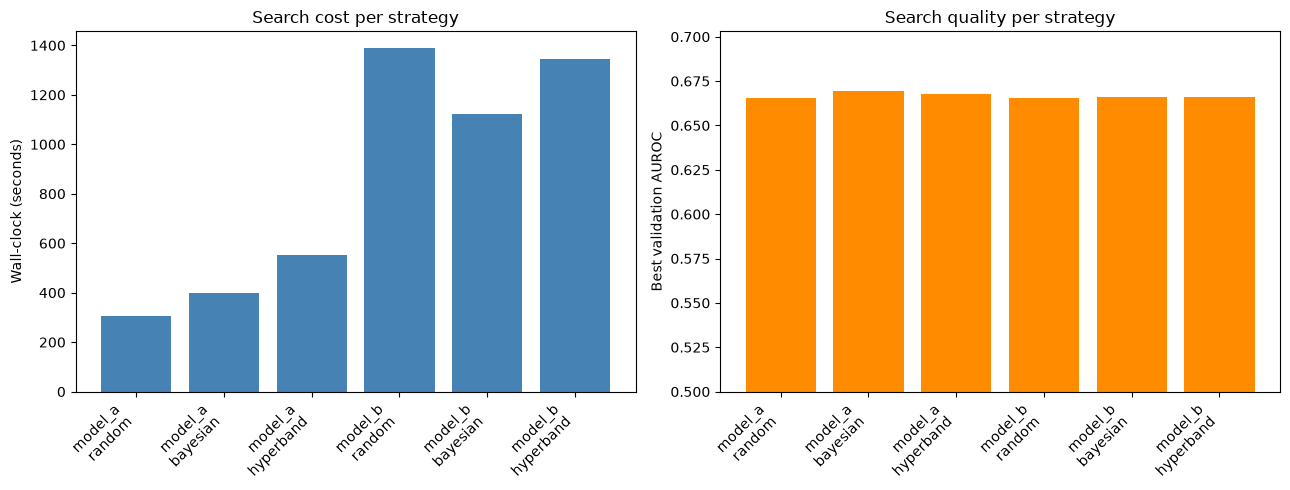

In [15]:
if len(comparison_ok) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    labels = [f"{row.model}\n{row.strategy}" for row in comparison_ok.itertuples()]
    x_pos = np.arange(len(comparison_ok))

    axes[0].bar(x_pos, comparison_ok["wall_clock_seconds"], color="steelblue")
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels(labels, rotation=45, ha="right")
    axes[0].set_ylabel("Wall-clock (seconds)")
    axes[0].set_title("Search cost per strategy")

    axes[1].bar(x_pos, comparison_ok["best_val_auc"], color="darkorange")
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(labels, rotation=45, ha="right")
    axes[1].set_ylabel("Best validation AUROC")
    axes[1].set_title("Search quality per strategy")
    axes[1].set_ylim(bottom=min(0.5, comparison_ok["best_val_auc"].min() - 0.02))

    plt.tight_layout()
    plt.show()
else:
    print("No successful search runs to chart - see the failures listed above.")

**Reading the comparison.** RandomSearch and Bayesian ran the same trial budget, so any wall-clock difference reflects Bayesian's surrogate-model overhead rather than more models trained; Bayesian earning a better `best_val_auc` at a similar count would be the payoff of its smarter sampling. Hyperband's position on wall-clock versus quality is the empirical answer to whether successive halving is worth its cost on this dataset - it is not guaranteed to win, and "it did not win here" is as informative as "it won".

## 8. Learning-rate range test

The learning rate above is picked from a fixed six-value grid. This section replaces that with a plotted, dataset-specific diagnostic (the LR range test): ramp the learning rate exponentially across one epoch, plot loss against learning rate on a log axis, and read off the elbow - the point of steepest descent, not the minimum-loss point, which sits on the edge of divergence. It cross-checks the tuned learning rates and justifies adding `ReduceLROnPlateau` to the final training in Section 9. The test uses the untuned architecture, to characterise the learning-rate axis for this architecture family independent of the tuner's final width/depth choice.

[2026-07-24 14:59:54] ===== Section 8: LR range test starting =====


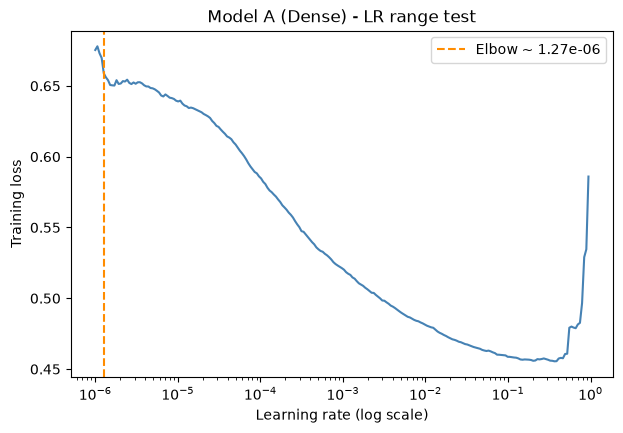

[2026-07-24 14:59:56] Model A (Dense): LR range test elbow ~ 1.27e-06


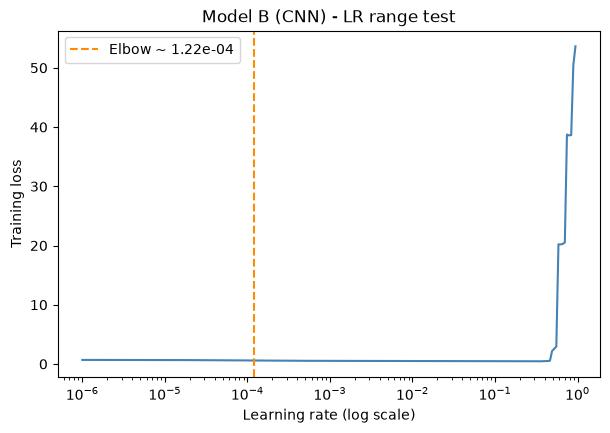

[2026-07-24 14:59:59] Model B (CNN): LR range test elbow ~ 1.22e-04
[2026-07-24 14:59:59] ===== Section 8: LR range test done =====


In [16]:
class LRRangeTestCallback(tf.keras.callbacks.Callback):
    """Exponentially ramps the learning rate across one epoch, recording loss per step."""

    def __init__(self, min_lr: float = 1e-6, max_lr: float = 1.0, n_steps: int = 100) -> None:
        super().__init__()
        self.min_lr = min_lr
        self.max_lr = max_lr
        self.n_steps = max(n_steps, 1)
        self.lrs: list = []
        self.losses: list = []
        self._step = 0

    def on_train_begin(self, logs: dict = None) -> None:
        """Initialise the optimizer's learning rate to `min_lr` before the sweep starts."""
        self.model.optimizer.learning_rate.assign(self.min_lr)

    def on_train_batch_end(self, batch: int, logs: dict = None) -> None:
        """Record the current (lr, loss) pair, then advance the LR exponentially."""
        self.lrs.append(float(self.model.optimizer.learning_rate.numpy()))
        self.losses.append(float(logs["loss"]))
        self._step += 1
        frac = min(self._step / self.n_steps, 1.0)
        new_lr = self.min_lr * (self.max_lr / self.min_lr) ** frac
        self.model.optimizer.learning_rate.assign(new_lr)

def find_lr_elbow(lrs: list, losses: list) -> float:
    """Locate the LR range test elbow (point of steepest smoothed loss descent)."""
    smoothed = pd.Series(losses).ewm(alpha=0.1).mean().to_numpy()
    gradients = np.gradient(smoothed)
    steepest_idx = int(np.argmin(gradients))
    return float(lrs[steepest_idx])

def build_baseline_dense() -> Sequential:
    """Notebook 2's untuned Model A architecture, for the LR range test only."""
    model = Sequential()
    model.add(Input(shape=(n_features,)))
    model.add(Dense(units=256, kernel_initializer="he_uniform", activation="relu"))
    model.add(Dropout(0.2))
    model.add(Dense(units=128, kernel_initializer="he_uniform", activation="relu"))
    model.add(Dropout(0.2))
    model.add(Dense(units=1, kernel_initializer="he_uniform", activation="sigmoid"))
    model.compile(optimizer="adam", loss="binary_crossentropy",
                  metrics=["accuracy", tf.keras.metrics.AUC(name="auc")])
    return model

def build_baseline_cnn() -> Sequential:
    """Notebook 2's untuned Model B architecture, for the LR range test only."""
    model = Sequential()
    model.add(Input(shape=(n_features, 1)))
    model.add(Conv1D(filters=64, kernel_size=2, activation="relu"))
    model.add(SpatialDropout1D(0.2))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(filters=128, kernel_size=2, activation="relu"))
    model.add(SpatialDropout1D(0.2))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Flatten())
    model.add(Dense(128, activation="relu"))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation="sigmoid"))
    model.compile(optimizer="adam", loss="binary_crossentropy",
                  metrics=["accuracy", tf.keras.metrics.AUC(name="auc")])
    return model

def run_lr_range_test(build_fn, x_tr: np.ndarray, y_tr: np.ndarray, model_name: str,
                       batch_size: int = 256) -> float:
    """Run the LR range test for one architecture and plot loss vs. learning rate."""
    tf.random.set_seed(RANDOM_STATE)
    model = build_fn()
    n_steps = int(np.ceil(len(x_tr) / batch_size))
    lr_callback = LRRangeTestCallback(min_lr=1e-6, max_lr=1.0, n_steps=n_steps)
    model.fit(x_tr, y_tr, batch_size=batch_size, epochs=1, callbacks=[lr_callback], verbose=0)

    elbow_lr = find_lr_elbow(lr_callback.lrs, lr_callback.losses)

    plt.figure(figsize=(7, 4.5))
    plt.plot(lr_callback.lrs, lr_callback.losses, color="steelblue")
    plt.axvline(elbow_lr, color="darkorange", linestyle="--", label=f"Elbow ~ {elbow_lr:.2e}")
    plt.xscale("log")
    plt.xlabel("Learning rate (log scale)")
    plt.ylabel("Training loss")
    plt.title(f"{model_name} - LR range test")
    plt.legend()
    plt.show()

    print(f"[{now()}] {model_name}: LR range test elbow ~ {elbow_lr:.2e}")
    return elbow_lr

def run_lr_range_test_safe(build_fn, x_tr: np.ndarray, y_tr: np.ndarray, model_name: str,
                            batch_size: int = 256):
    """Run the LR range test, tolerating a transient GPU/XLA compilation failure."""
    try:
        return run_lr_range_test(build_fn, x_tr, y_tr, model_name, batch_size=batch_size)
    except Exception as exc:  # noqa: BLE001 - deliberately broad, see Why above
        print(f"[{now()}] {model_name}: LR range test FAILED "
              f"({type(exc).__name__}: {exc}) - skipping, continuing with the rest of the notebook.")
        return None

print(f"[{now()}] ===== Section 8: LR range test starting =====")
elbow_lr_a = run_lr_range_test_safe(build_baseline_dense, x_train_dense, y_train, "Model A (Dense)")
elbow_lr_b = run_lr_range_test_safe(build_baseline_cnn, x_train_cnn, y_train, "Model B (CNN)")
print(f"[{now()}] ===== Section 8: LR range test done =====")

**Reading the range test.** The elbow is where loss falls fastest without being on the edge of divergence - a defensible single learning rate derived from a plot rather than a list. Comparing it against the value each tuned configuration selected is a useful second check: broad agreement corroborates the tuner; a large gap would suggest the coarse grid missed the optimum between its fixed points. Either way, `ReduceLROnPlateau` in Section 9 removes the need to commit to one fixed value, decaying automatically once validation loss plateaus.

## 9. Retrain the winning configuration

For each model, the strategy with the highest `best_val_auc` is selected and its hyperparameters are retrained from scratch on the full training fold. The tuner's own trained weights are not reused, since a search trial may have stopped early; a clean retrain with the final callbacks (`EarlyStopping` + `ReduceLROnPlateau`) is the safer choice. `ReduceLROnPlateau` is added here rather than during the search, to keep each trial's objective stable and comparable across strategies.

In [17]:
def select_best_strategy(model_name: str):
    """Pick the strategy with the highest `best_val_auc` for one model."""
    candidates = {
        strategy_name: result["best_val_auc"]
        for (m, strategy_name), result in search_results.items()
        if m == model_name and result.get("status") == "ok"
    }
    if not candidates:
        return None
    return max(candidates, key=candidates.get)

def retrain_best_config(model_name: str, hypermodel: kt.HyperModel, best_strategy: str,
                         x_tr: np.ndarray, y_tr: np.ndarray, x_va: np.ndarray, y_va: np.ndarray):
    """Retrain the winning hyperparameter configuration with EarlyStopping + ReduceLROnPlateau."""
    tuner = tuners[(model_name, best_strategy)]
    best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
    batch_size = best_hp.values["batch_size"]

    tf.random.set_seed(RANDOM_STATE)
    model = hypermodel.build(best_hp)

    early_stopping = EarlyStopping(monitor="val_auc", mode="max",
                                    patience=EARLY_STOPPING_PATIENCE, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=0)

    print(f"[{now()}] ===== Retraining {model_name} with the {best_strategy} winning config "
          f"(batch_size={batch_size}) =====")
    t0 = time.time()
    history = model.fit(
        x_tr, y_tr,
        validation_data=(x_va, y_va),
        batch_size=batch_size,
        epochs=RETRAIN_MAX_EPOCHS,
        callbacks=[early_stopping, reduce_lr],
        verbose=2,
    )
    wall_clock = time.time() - t0
    print(f"[{now()}] ===== {model_name} retrained for {len(history.history['loss'])} epochs "
          f"in {wall_clock:.1f}s =====")
    return model, history, dict(best_hp.values)

best_strategy_a = select_best_strategy("model_a")
best_strategy_b = select_best_strategy("model_b")
print(f"Model A - best strategy: {best_strategy_a}")
print(f"Model B - best strategy: {best_strategy_b}")

Model A - best strategy: bayesian
Model B - best strategy: bayesian


### 9.1 Model A

In [18]:
model_a_tuned, history_a_tuned, best_hp_a_values = None, None, None
if best_strategy_a is not None:
    try:
        model_a_tuned, history_a_tuned, best_hp_a_values = retrain_best_config(
            "model_a", dense_hypermodel, best_strategy_a, x_train_dense, y_train, x_val_dense, y_val,
        )
        print("Model A winning hyperparameters:", json.dumps(best_hp_a_values, indent=2))
    except Exception as exc:  # noqa: BLE001 - retrain is not itself in a sweep loop
                              # but a failure here must not prevent Model B's retrain/
                              # evaluation/save below (robustness requirement)
        print(f"[{now()}] Model A retrain FAILED ({type(exc).__name__}: {exc}) - "
              f"falling back to the untuned Notebook 2 model below.")
else:
    print(f"[{now()}] All three search strategies failed for Model A - retrain skipped. "
          f"Model A's tuned result below falls back to the untuned Notebook 2 model.")

[2026-07-24 15:00:00] ===== Retraining model_a with the bayesian winning config (batch_size=256) =====
Epoch 1/100


233/233 - 1s - 5ms/step - accuracy: 0.8752 - auc: 0.5724 - loss: 0.3782 - val_accuracy: 0.8865 - val_auc: 0.6482 - val_loss: 0.3459 - learning_rate: 0.0010


Epoch 2/100


233/233 - 0s - 2ms/step - accuracy: 0.8851 - auc: 0.6021 - loss: 0.3528 - val_accuracy: 0.8866 - val_auc: 0.6556 - val_loss: 0.3430 - learning_rate: 0.0010


Epoch 3/100


...

Epoch 22/100


233/233 - 0s - 2ms/step - accuracy: 0.8864 - auc: 0.6637 - loss: 0.3355 - val_accuracy: 0.8863 - val_auc: 0.6685 - val_loss: 0.3367 - learning_rate: 2.5000e-04


Epoch 23/100


233/233 - 0s - 2ms/step - accuracy: 0.8865 - auc: 0.6659 - loss: 0.3349 - val_accuracy: 0.8863 - val_auc: 0.6686 - val_loss: 0.3367 - learning_rate: 2.5000e-04


[2026-07-24 15:00:10] ===== model_a retrained for 23 epochs in 9.6s =====
Model A winning hyperparameters: {
  "activation": "tanh",
  "hl1_units": 128,
  "dropout_1": 0.2,
  "hl2_units": 64,
  "dropout_2": 0.4,
  "learning_rate": 0.001,
  "optimizer": "adam",
  "batch_size": 256
}


,accuracy,auc,loss,val_accuracy,val_auc,val_loss,learning_rate
epoch,,,,,,,
0,0.875195,0.572408,0.378197,0.886501,0.648150,0.345940,0.00100
1,0.885060,0.602149,0.352783,0.886551,0.655552,0.343017,0.00100
21,0.886436,0.663654,0.335451,0.886350,0.668504,0.336675,0.00025
22,0.886520,0.665857,0.334898,0.886350,0.668574,0.336748,0.00025


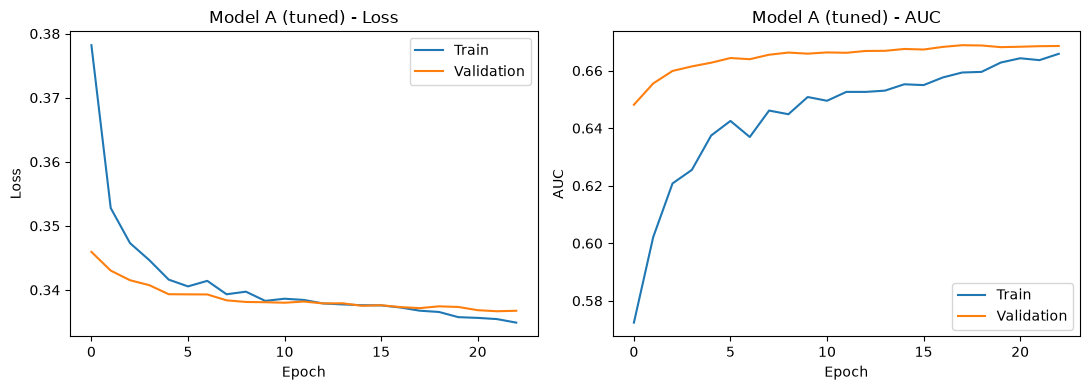

In [19]:
if history_a_tuned is not None:
    hist_df_a_tuned = pd.DataFrame(history_a_tuned.history)
    hist_df_a_tuned.index.name = "epoch"
    display(pd.concat([hist_df_a_tuned.head(2), hist_df_a_tuned.tail(2)]))
    plot_learning_curves(history_a_tuned, model_name="Model A (tuned)")

### 9.2 Model B

In [20]:
model_b_tuned, history_b_tuned, best_hp_b_values = None, None, None
if best_strategy_b is not None:
    try:
        model_b_tuned, history_b_tuned, best_hp_b_values = retrain_best_config(
            "model_b", cnn_hypermodel, best_strategy_b, x_train_cnn, y_train, x_val_cnn, y_val,
        )
        print("Model B winning hyperparameters:", json.dumps(best_hp_b_values, indent=2))
    except Exception as exc:  # noqa: BLE001 - see the matching comment in
        print(f"[{now()}] Model B retrain FAILED ({type(exc).__name__}: {exc}) - "
              f"falling back to the untuned Notebook 2 model below.")
else:
    print(f"[{now()}] All three search strategies failed for Model B - retrain skipped. "
          f"Model B's tuned result below falls back to the untuned Notebook 2 model.")

[2026-07-24 15:00:11] ===== Retraining model_b with the bayesian winning config (batch_size=256) =====
Epoch 1/100


233/233 - 3s - 12ms/step - accuracy: 0.8838 - auc: 0.5909 - loss: 0.3545 - val_accuracy: 0.8861 - val_auc: 0.6499 - val_loss: 0.3400 - learning_rate: 0.0010


Epoch 2/100


233/233 - 2s - 8ms/step - accuracy: 0.8862 - auc: 0.6194 - loss: 0.3469 - val_accuracy: 0.8861 - val_auc: 0.6550 - val_loss: 0.3393 - learning_rate: 0.0010


Epoch 3/100


...

Epoch 10/100


233/233 - 2s - 8ms/step - accuracy: 0.8863 - auc: 0.6498 - loss: 0.3390 - val_accuracy: 0.8860 - val_auc: 0.6616 - val_loss: 0.3377 - learning_rate: 0.0010


Epoch 11/100


233/233 - 2s - 8ms/step - accuracy: 0.8864 - auc: 0.6523 - loss: 0.3386 - val_accuracy: 0.8862 - val_auc: 0.6628 - val_loss: 0.3370 - learning_rate: 5.0000e-04


[2026-07-24 15:00:33] ===== model_b retrained for 11 epochs in 22.3s =====
Model B winning hyperparameters: {
  "activation": "relu",
  "filters_1": 96,
  "kernel_1": 2,
  "spatial_dropout_1": 0.30000000000000004,
  "filters_2": 48,
  "kernel_2": 3,
  "spatial_dropout_2": 0.4,
  "dense_units": 160,
  "dense_dropout": 0.30000000000000004,
  "learning_rate": 0.001,
  "optimizer": "rmsprop",
  "batch_size": 256
}


,accuracy,auc,loss,val_accuracy,val_auc,val_loss,learning_rate
epoch,,,,,,,
0,0.883768,0.590922,0.354490,0.886149,0.649896,0.339997,0.0010
1,0.886150,0.619372,0.346883,0.886098,0.655003,0.339252,0.0010
9,0.886285,0.649771,0.339036,0.886048,0.661554,0.337678,0.0010
10,0.886385,0.652295,0.338591,0.886199,0.662779,0.336992,0.0005


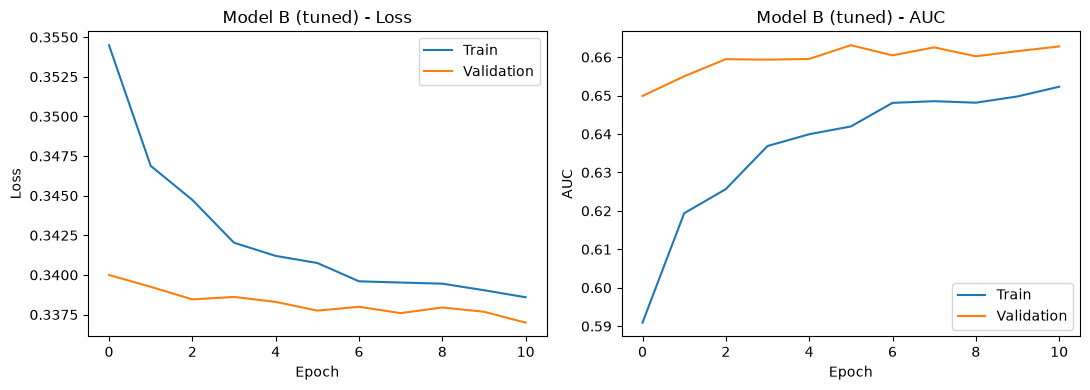

In [21]:
if history_b_tuned is not None:
    hist_df_b_tuned = pd.DataFrame(history_b_tuned.history)
    hist_df_b_tuned.index.name = "epoch"
    display(pd.concat([hist_df_b_tuned.head(2), hist_df_b_tuned.tail(2)]))
    plot_learning_curves(history_b_tuned, model_name="Model B (tuned)")

## 10. Evaluate on the test set - touched once, at the end

Every decision above used only the training and validation folds. The test set is loaded in Section 2 but not looked at until here. Metrics: AUROC, PR-AUC and minority-class F1 at both the default 0.5 threshold and the validation-tuned threshold, as in the previous notebook.

Late in an unbound run on an 8 GB card, six searches plus two retrains can leave little GPU headroom, so the evaluation catches a late OOM and records that row as unavailable rather than losing the rest of the notebook.

In [22]:
def evaluate_tuned_model(model, x_va: np.ndarray, y_va: np.ndarray,
                          x_te: np.ndarray, y_te: np.ndarray) -> dict:
    """Evaluate a retrained model on the test set, choosing the threshold on validation only."""
    y_proba_val = model.predict(x_va, verbose=0).ravel()
    tuned_threshold = select_threshold_max_f1(y_va, y_proba_val)

    y_proba_test = model.predict(x_te, verbose=0).ravel()
    return {
        "threshold_0.5": compute_extended_metrics(y_te, y_proba_test, threshold=0.5),
        "threshold_tuned": compute_extended_metrics(y_te, y_proba_test, threshold=tuned_threshold),
        "selected_threshold": tuned_threshold,
    }

def evaluate_tuned_model_safe(model, x_va: np.ndarray, y_va: np.ndarray,
                               x_te: np.ndarray, y_te: np.ndarray, model_name: str):
    """Evaluate a retrained model, tolerating a late-session GPU OOM."""
    if model is None:
        return None
    try:
        return evaluate_tuned_model(model, x_va, y_va, x_te, y_te)
    except Exception as exc:  # noqa: BLE001 - see Why above
        print(f"[{now()}] {model_name} test-set evaluation FAILED "
              f"({type(exc).__name__}: {exc}) - recorded as unavailable, continuing.")
        return None

print(f"[{now()}] ===== Section 10: test-set evaluation (touched once) starting =====")

eval_a_tuned = evaluate_tuned_model_safe(model_a_tuned, x_val_dense, y_val, x_test_dense, y_test, "Model A")
eval_b_tuned = evaluate_tuned_model_safe(model_b_tuned, x_val_cnn, y_val, x_test_cnn, y_test, "Model B")

print(f"[{now()}] ===== Section 10: test-set evaluation done =====")

[2026-07-24 15:00:34] ===== Section 10: test-set evaluation (touched once) starting =====


[2026-07-24 15:00:36] ===== Section 10: test-set evaluation done =====


**Tuned vs. untuned - one table**

In [23]:
tuned_vs_untuned_rows = []
for label, untuned_key, tuned_entry in [
    ("Model A - untuned (Notebook 2)", "model_a_dense", None),
    ("Model A - tuned", None, eval_a_tuned),
    ("Model B - untuned (Notebook 2)", "model_b_cnn", None),
    ("Model B - tuned", None, eval_b_tuned),
]:
    entry = results_phase3["models"][untuned_key] if untuned_key is not None else tuned_entry
    if entry is None:
        continue
    tuned_vs_untuned_rows.append({
        "model": label,
        "roc_auc": entry["threshold_0.5"]["roc_auc"],
        "pr_auc": entry["threshold_0.5"]["pr_auc"],
        "minority_f1_at_0.5": entry["threshold_0.5"]["minority_f1"],
        "minority_f1_at_tuned_thr": entry["threshold_tuned"]["minority_f1"],
        "selected_threshold": entry["selected_threshold"],
    })

tuned_vs_untuned_df = pd.DataFrame(tuned_vs_untuned_rows).set_index("model")
tuned_vs_untuned_df.round(4)

,roc_auc,pr_auc,minority_f1_at_0.5,minority_f1_at_tuned_thr,selected_threshold
model,,,,,
Model A - untuned (Notebook 2),0.6627,0.2174,0.0079,0.2755,0.1532
Model A - tuned,0.6635,0.2182,0.0035,0.2736,0.1220
Model B - untuned (Notebook 2),0.6635,0.2155,0.0053,0.2815,0.1433
Model B - tuned,0.6597,0.2128,0.0009,0.2784,0.1341


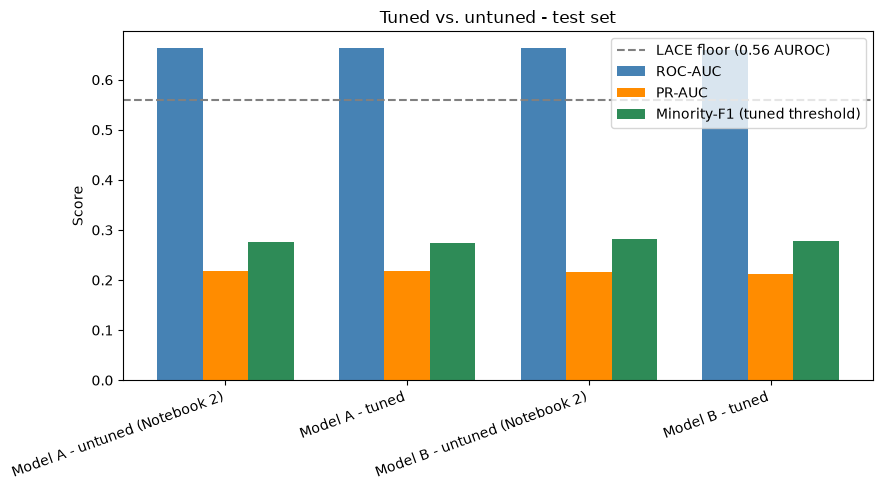

In [24]:
fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(len(tuned_vs_untuned_df))
width = 0.25
ax.bar(x_pos - width, tuned_vs_untuned_df["roc_auc"], width, label="ROC-AUC", color="steelblue")
ax.bar(x_pos, tuned_vs_untuned_df["pr_auc"], width, label="PR-AUC", color="darkorange")
ax.bar(x_pos + width, tuned_vs_untuned_df["minority_f1_at_tuned_thr"], width,
       label="Minority-F1 (tuned threshold)", color="seagreen")
ax.axhline(0.56, linestyle="--", color="gray", label="LACE floor (0.56 AUROC)")
ax.set_xticks(x_pos)
ax.set_xticklabels(tuned_vs_untuned_df.index, rotation=20, ha="right")
ax.set_ylabel("Score")
ax.set_title("Tuned vs. untuned - test set")
ax.legend()
plt.tight_layout()
plt.show()

**Reading the comparison.** A flat or negative delta between tuned and untuned is a legitimate, expected result on this dataset, not a search failure: the trustworthy neural-network ceiling here is 0.58-0.61 AUROC, and tuning cannot manufacture signal the 89-feature encounter-level representation does not contain. What tuning can do is find the best operating point within that ceiling, which is what the task asks for.

## 11. Save models and results

Saves the tuned models and appends the tuned-vs-untuned comparison to `results_phase4.json`, alongside the per-strategy search results saved incrementally in Section 6.

In [25]:
def save_model_safe(model, path: Path, model_name: str) -> None:
    """Save a model, tolerating a late-session GPU/IO failure (robustness requirement)."""
    if model is None:
        return
    try:
        model.save(path)
        print(f"[{now()}] Saved {path.relative_to(PROJECT_ROOT)}")
    except Exception as exc:  # noqa: BLE001 - a save failure must not prevent
                              # results_phase4.json (below) from still being written
        print(f"[{now()}] Saving {model_name} FAILED ({type(exc).__name__}: {exc}) - "
              f"continuing without it.")

save_model_safe(model_a_tuned, ARTIFACTS_DIR / "model_a_tuned.keras", "Model A")
save_model_safe(model_b_tuned, ARTIFACTS_DIR / "model_b_tuned.keras", "Model B")

[2026-07-24 15:00:36] Saved artifacts/model_a_tuned.keras
[2026-07-24 15:00:36] Saved artifacts/model_b_tuned.keras


In [26]:
results_phase4_final = load_results_phase4()
results_phase4_final["tuned_vs_untuned"] = tuned_vs_untuned_df.reset_index().to_dict(orient="records")
results_phase4_final["retrain"] = {
    "model_a": {
        "best_strategy": best_strategy_a,
        "best_hyperparameters": best_hp_a_values,
    },
    "model_b": {
        "best_strategy": best_strategy_b,
        "best_hyperparameters": best_hp_b_values,
    },
}
results_phase4_final["lr_range_test"] = {
    "model_a_elbow_lr": elbow_lr_a,
    "model_b_elbow_lr": elbow_lr_b,
}
save_results_phase4(results_phase4_final)
print(f"[{now()}] Saved final artifacts/results_phase4.json "
      f"(search_runs, tuned_vs_untuned, retrain, lr_range_test)")

[2026-07-24 15:00:36] Saved final artifacts/results_phase4.json (search_runs, tuned_vs_untuned, retrain, lr_range_test)


## 12. Discussion

**Did tuning help?** Section 10's table is the answer, read against the established 0.58-0.61 neural-network ceiling. A small positive delta is the expected honest outcome of tuning a low-signal, ~11.39%-positive target; a flat or negative delta is equally legitimate to report - it would say the untuned starting point (256/128 units, dropout 0.2, Adam, batch 256) was already near this representation's ceiling.

**Which strategy was most efficient?** Section 7's table is the measured answer. The general expectation, not guaranteed here: RandomSearch is cheapest per trial but least sample-efficient; Bayesian should match or beat it in fewer trials once its surrogate has enough observations; Hyperband should be cheapest on wall-clock per unit of coverage, provided early-epoch AUROC is a faithful proxy for late-epoch AUROC - if it is not, it will discard good-but-slow-starting configurations and reach a worse best score despite a lower cost. Whichever pattern appears is the interesting result, since it is a property of this dataset rather than a general fact.

**Limitations.** Depth (2 hidden layers; 2 conv blocks) and pooling size were fixed, with width, regularisation and optimisation searched instead; a wider, depth-searching space is future work. The LR range test characterised the untuned architecture, not the specific tuned configuration. The tuned models are the input to the evaluation notebook, which carries the full metric suite and model-selection discussion forward.